<a href="https://colab.research.google.com/github/Damon0427/projectCheckPoint01/blob/main/Project_CheckPoint1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset Reading && Sampling frames

This notebook is completed by using Google colab, and the saved file is located in Google Drive.

If you would like to run this notebook in your local machinese,
You could simplyly change the "deepfake_dir" , "original_dir", and "save_dir" to your local file address.

In [1]:
# use for face location
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.3 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
import os
import mediapipe as mp
from tqdm import tqdm

data_dir = Path("/content/sample_data")
# Get accss to the Google Drive to read the dataset
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
deepfake_dir = "/content/drive/MyDrive/sample_data/manipulated_sequences/Deepfakes/c23/videos"
original_dir = "/content/drive/MyDrive/sample_data/original_sequences/youtube/c23/videos"
save_dir = "/content/drive/MyDrive/Deepfake_Project_Data"
num_frames = 1
target_size = (224, 224)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)


In [4]:
print(mp.__version__)


0.10.33


In [5]:
# init the mediapip object for face location, and using the exist model from mediapip documentation
# https://ai.google.dev/edge/mediapipe/solutions/vision/face_detector#blazeface_short-range
BaseOptions = mp.tasks.BaseOptions
FaceDetector = mp.tasks.vision.FaceDetector
FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions

options = FaceDetectorOptions(
    base_options=BaseOptions(model_asset_path="/content/drive/MyDrive/Model/blaze_face_short_range.tflite"),
    running_mode=mp.tasks.vision.RunningMode.IMAGE,
    min_detection_confidence=0.5
)
face_detector = FaceDetector.create_from_options(options)

## Frame Extraction, and Save into Google Drive

This two function is extrat frames from video, and save them into the google Drive, so we don't have to rerun the whole thing again and again. ( I highly suggest running the whole note book on google colab, otherwise, you may need to reset the save path into your local file path)

In [7]:
import cv2
# This function is for sampling and data cleaning, and processing(Fram sampling, face location,Crop and Normalizing,)
def process_video_to_faces(video_path, num_frames, target_size):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    # using Equidistant Sampling for the baseline .
    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    face_sequence = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue

        # BGR transfor to RGB, so mediapip are able to process
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

        results = face_detector.detect(mp_image)

        if results.detections:
            bbox = results.detections[0].bounding_box
            ih, iw, _ = frame.shape

            # adding a 10% margin to the egege, to see if there any deepfake cues.
            margin_w = int(bbox.width * 0.1)
            margin_h = int(bbox.height * 0.1)

            x = int(max(0, bbox.origin_x - margin_w // 2))
            y = int(max(0, bbox.origin_y - margin_h // 2))
            w = int(min(iw - x, bbox.width + margin_w))
            h = int(min(ih - y, bbox.height + margin_h))

            face_crop = frame_rgb[y:y+h, x:x+w]
            if face_crop.size > 0:
                # resize the frame to 224*224
                face_crop = cv2.resize(face_crop, target_size)
                # this is normalization
                face_sequence.append(face_crop.astype(np.float32) / 255.0)

    cap.release()

    # if the frames capture is less than 16, throws away
    return np.array(face_sequence) if len(face_sequence) == num_frames else None

In [8]:
import gc
def run_batch_processing(source_dir, label_name, label_value, batch_size=50):
    if not os.path.exists(source_dir):
        print(f"can't find  {source_dir}")
        return

    video_files = [f for f in os.listdir(source_dir) if f.endswith('.mp4')]
    current_data, current_labels = [], []
    batch_idx = 1

    print(f"handing {label_name} video，total: {len(video_files)}")

    ## iteralying each video and extrat num_frames for each video
    for i, filename in enumerate(tqdm(video_files)):
        video_path = os.path.join(source_dir, filename)
        faces = process_video_to_faces(video_path, num_frames, target_size)

        if faces is not None:
            current_data.append(faces)
            current_labels.append(label_value)

        # if we have enought bath, then save it into google drive
        if len(current_data) == batch_size or i == len(video_files) - 1:
            if len(current_data) > 0:
                np.save(f"{save_dir}/{label_name}_data_b{batch_idx}.npy", np.array(current_data))
                np.save(f"{save_dir}/{label_name}_label_b{batch_idx}.npy", np.array(current_labels))
                batch_idx += 1
                del current_data, current_labels
                gc.collect()
                current_data, current_labels = [], []

    # Save the file into google drive
    print(f"{label_name} video handle successfuly！file saved at: {save_dir}")


# real video label as 0  deepfake video label as 1
# And extract the frame from video, and save them into drive folder
run_batch_processing(original_dir, "real", 0)
run_batch_processing(deepfake_dir, "fake", 1)

handing real video，total: 150


100%|██████████| 150/150 [00:41<00:00,  3.63it/s]


real video handle successfuly！file saved at: /content/drive/MyDrive/Deepfake_Project_Data
handing fake video，total: 150


100%|██████████| 150/150 [01:42<00:00,  1.46it/s]

fake video handle successfuly！file saved at: /content/drive/MyDrive/Deepfake_Project_Data


In [6]:
import glob


# get all of the data from google drive to aviod rerunning the extract frames function again and again.
def load_processed_data(data_dir):
    data_files = sorted(glob.glob(f"{data_dir}/*_data_b*.npy"))
    label_files = sorted(glob.glob(f"{data_dir}/*_label_b*.npy"))

    X = np.concatenate([np.load(f) for f in data_files])
    y = np.concatenate([np.load(f) for f in label_files])

    print(f"Data loading complete!")
    print(f"Total Features (X) shape: {X.shape}")
    print(f"Total Labels (y) shape: {y.shape}")
    return X, y

X, y = load_processed_data(save_dir)

Data loading complete!
Total Features (X) shape: (286, 1, 224, 224, 3)
Total Labels (y) shape: (286,)


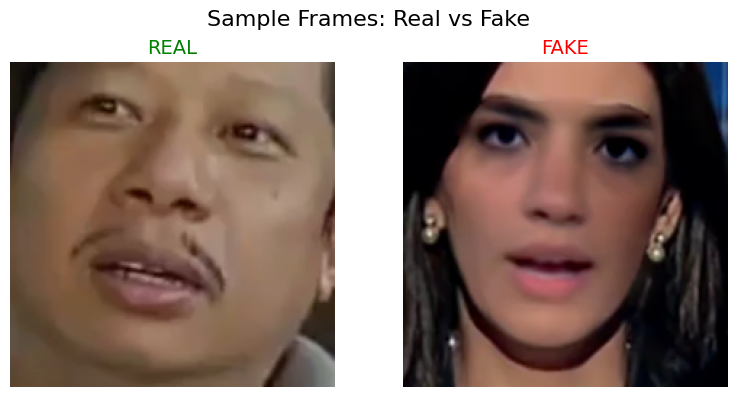

In [7]:
# This function is shows how the frame looks like, after the data had been crop, and process.

import matplotlib.pyplot as plt

real_indices = np.where(y == 0)[0]
fake_indices = np.where(y == 1)[0]

real_idx = np.random.choice(real_indices)
fake_idx = np.random.choice(fake_indices)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(X[real_idx, 0])
axes[0].set_title("REAL", fontsize=14, color='green')
axes[0].axis('off')

axes[1].imshow(X[fake_idx, 0])
axes[1].set_title("FAKE", fontsize=14, color='red')
axes[1].axis('off')

plt.suptitle("Sample Frames: Real vs Fake", fontsize=16)
plt.tight_layout()
plt.show()

# Exploratory Data Analysis (EDA)

## Class Balance:

/tmp/ipykernel_3164/1010460765.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette=['#3498db', '#e74c3c'])


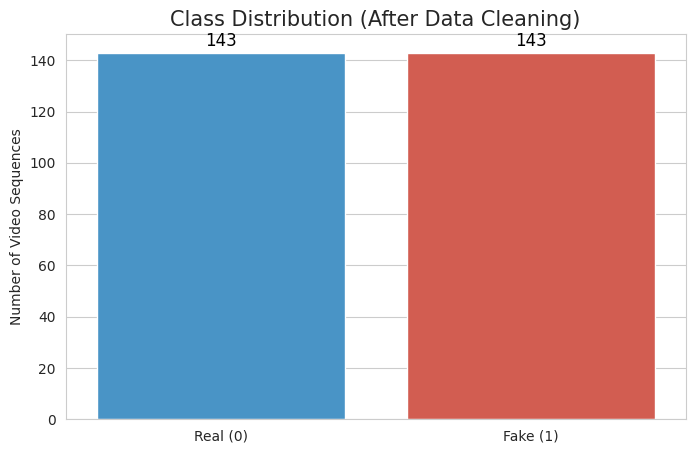

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

counts = pd.Series(y).value_counts().sort_index()
labels = ['Real (0)', 'Fake (1)']

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = sns.barplot(x=labels, y=counts.values, palette=['#3498db', '#e74c3c'])

# using histograms to shows the distribution after data cleaning
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title("Class Distribution (After Data Cleaning)", fontsize=15)
plt.ylabel("Number of Video Sequences")
plt.show()

## Univariate Analysis:

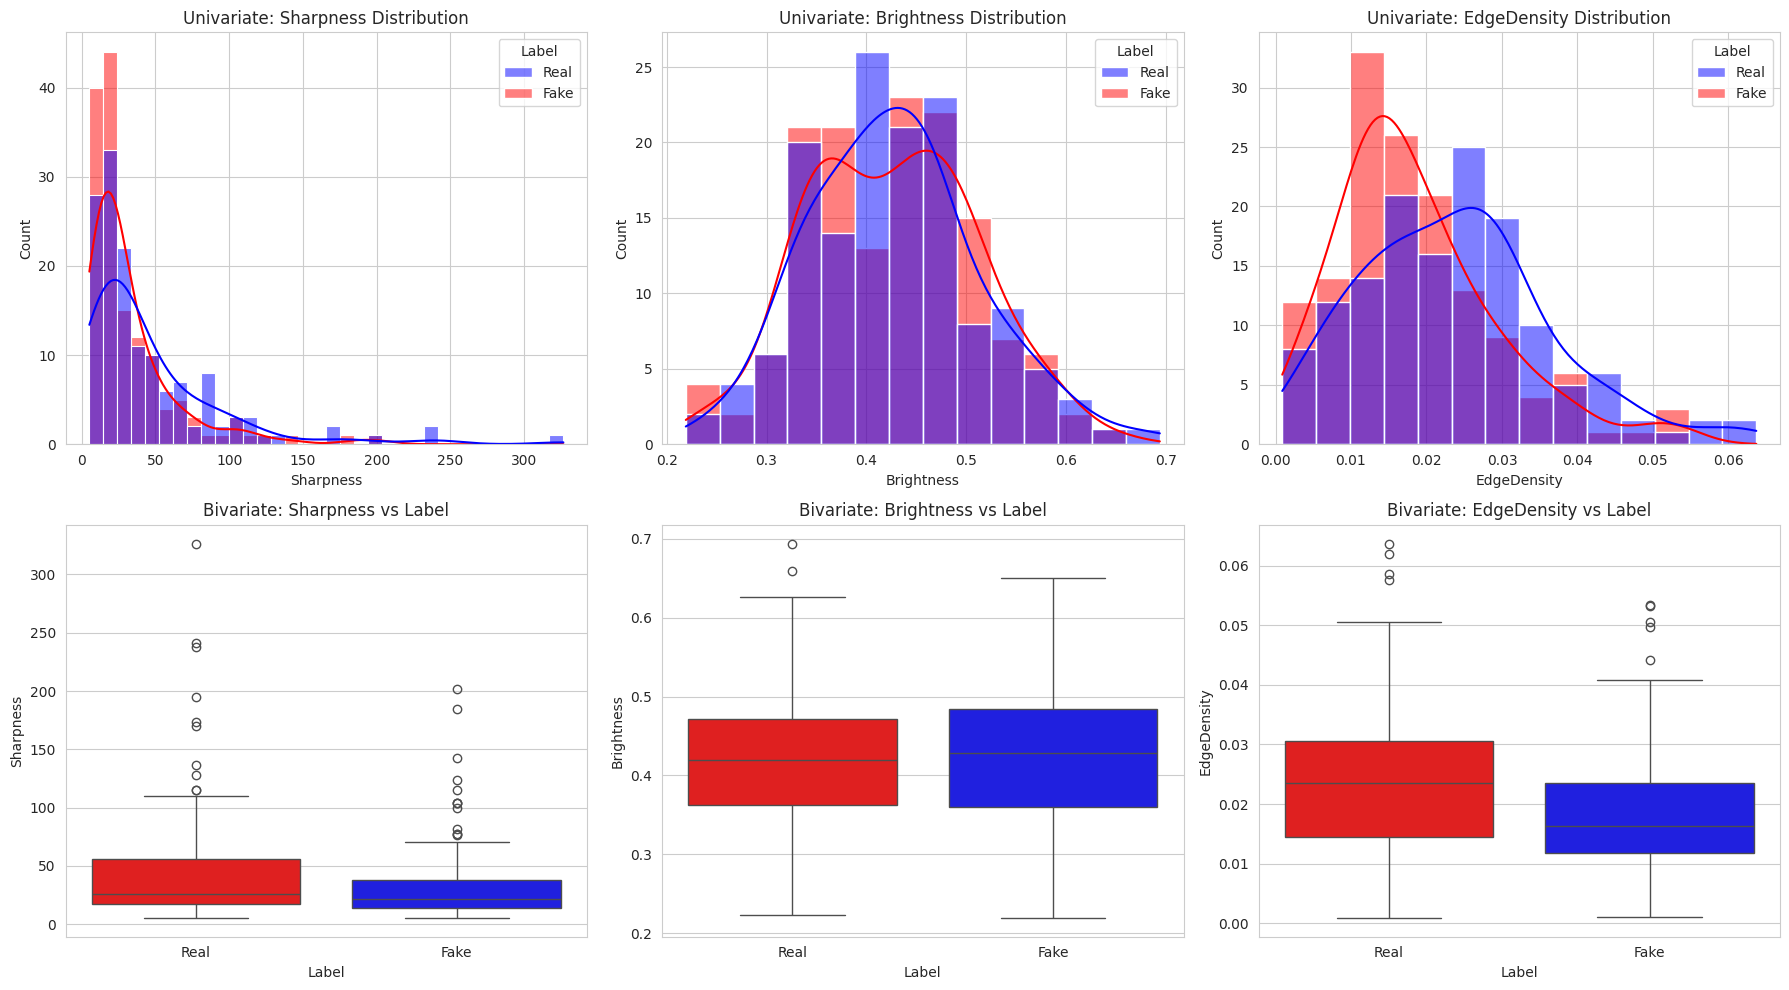

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

sharpness_list = []
edge_density_list = []

# Calculated their sharpness, gray, density, and edges for plotting
for video in X:
    frame = video[0]
    gray = cv2.cvtColor((frame * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness_list.append(sharpness)

    edges = cv2.Canny(gray, 100, 200)
    density = np.sum(edges > 0) / edges.size
    edge_density_list.append(density)

mean_sharpness = np.array(sharpness_list)
edge_density = np.array(edge_density_list)
mean_brightness = X[:, 0].mean(axis=(1, 2, 3))

# make a dataframe for plotting
df_eda = pd.DataFrame({
    'Brightness':  mean_brightness,
    'Sharpness':   mean_sharpness,
    'EdgeDensity': edge_density,
    'Label': ['Real' if i == 0 else 'Fake' for i in y]
})

features = ['Sharpness', 'Brightness', 'EdgeDensity']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# build a plot that shows features to label (Univariate and Bivariate)
for col, feature in enumerate(features):
    sns.histplot(data=df_eda, x=feature, hue='Label', kde=True,
                 ax=axes[0, col], palette=['blue', 'red'], alpha=0.5,
                 hue_order=['Real', 'Fake'])
    axes[0, col].set_title(f'Univariate: {feature} Distribution')


for col, feature in enumerate(features):
    sns.boxplot(data=df_eda, x='Label', y=feature,
                ax=axes[1, col], palette=['blue', 'red'],
                order=['Real', 'Fake'], hue='Label', legend=False)
    axes[1, col].set_title(f'Bivariate: {feature} vs Label')

plt.tight_layout()
plt.show()


## Bivariate Analysis:

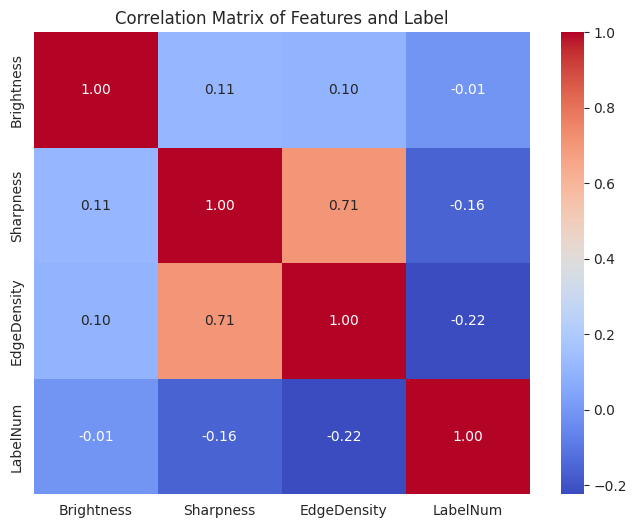

In [11]:
# Correlation Matrix
corr_df = df_eda[['Brightness', 'Sharpness', 'EdgeDensity']].copy()
corr_df['LabelNum'] = (df_eda['Label'] == 'Fake').astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features and Label')
plt.show()

#Model Init

## Resnet

In [38]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from scipy.interpolate import interp1d
from scipy.optimize import brentq
import numpy as np
import random


In [41]:
tf.random.set_seed(132)
np.random.seed(132)
random.seed(132)

# I am doing the single frame for detection, so I need to reshape the shape to 4 dimentsion
# when related to mutle frames detection with vit, the reshape function can be remove.

X_frames = X.reshape(-1, 224, 224, 3)
y_frames = np.repeat(y, num_frames)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_frames, y_frames,
    test_size=0.3,
    stratify=y_frames,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train label dist: real={np.sum(y_train==0)}, fake={np.sum(y_train==1)}")


Train: (200, 224, 224, 3), Val: (43, 224, 224, 3), Test: (43, 224, 224, 3)
Train label dist: real=100, fake=100


In [42]:
def build_resnet50_baseline():
    # Load ImageNet pretrained weights,and freed the top layer
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze all base layers → only train the new head
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))

    # ResNet expects [0,255] scaled by its own preprocessor
    x = tf.keras.applications.resnet50.preprocess_input(inputs * 255.0)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name='ResNet50_Baseline')
    return model

resnet_model = build_resnet50_baseline()

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

resnet_model.summary()

Model: "ResNet50_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Multiply)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_9          │ (None, 224, 224)  │          0 │ multiply_3[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_10         │ (None, 224, 224)  │          0 │ multiply_3[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_11         │ (None, 224, 224)  │          0 │ multiply_3[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_3 (Stack)     │ (None, 224, 224,  │          0 │ get_item_9[0][0], │
│                     │ 3)                │            │ get_item_10[0][0… │
│                     │                   │            │ get_item_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 224, 224,  │          0 │ stack_3[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_3[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │        129 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [43]:
# Training the model with X_train and y_train, I am doing 10 epochs, and apply earlystopp to keep the best round of performance.
history_frozen = resnet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 914ms/step - accuracy: 0.4650 - auc: 0.4901 - loss: 1.2105 - val_accuracy: 0.5349 - val_auc: 0.4816 - val_loss: 0.7869
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6550 - auc: 0.7292 - loss: 0.6147 - val_accuracy: 0.4884 - val_auc: 0.5271 - val_loss: 0.7527
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7100 - auc: 0.7427 - loss: 0.5986 - val_accuracy: 0.3953 - val_auc: 0.5671 - val_loss: 0.8048
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6900 - auc: 0.7582 - loss: 0.5808 - val_accuracy: 0.4419 - val_auc: 0.5790 - val_loss: 0.7764
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7450 - auc: 0.8240 - loss: 0.5288 - val_accuracy: 0.5116 - val_auc: 0.6071 - val_loss: 0.7393
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.7950 - auc: 0.8794 - loss: 0.4658 - val_accuracy: 0.4884 - val_auc: 0.6147 - val_loss: 0.7701
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59m

## Performance Metrix

In [45]:
y_prob = resnet_model.predict(X_test).flatten()   # predicted probabilities
y_pred = (y_prob >= 0.6).astype(int)              # binary predictions

# Accuracy
accuracy = (y_pred == y_test).mean()

# FAR: fake predicted as real  (miss)
# FRR: real predicted as fake  (false alarm)
FAR = ((y_pred[y_test == 1]) == 0).mean()
FRR = ((y_pred[y_test == 0]) == 1).mean()

# EER via ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

print("ResNet-50 Baseline — Test Set Results")
print(f"Accuracy : {accuracy:.4f}")
print(f"FAR      : {FAR:.4f}  (fake predicted as real)")
print(f"FRR      : {FRR:.4f}  (real predicted as fake)")
print(f"EER      : {eer:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step 
ResNet-50 Baseline — Test Set Results
Accuracy : 0.6744
FAR      : 0.4762  (fake predicted as real)
FRR      : 0.1818  (real predicted as fake)
EER      : 0.3810


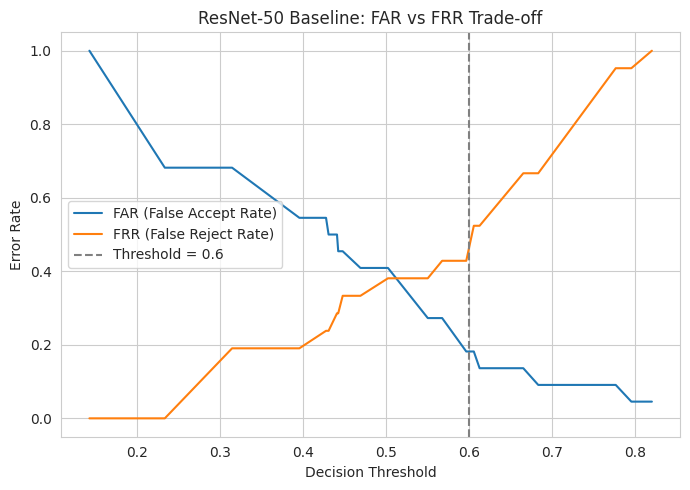

Plot saved as resnet50_far_frr.png


In [46]:
import matplotlib.pyplot as plt

fnr = 1 - tpr   # FNR = FRR over all thresholds

plt.figure(figsize=(7, 5))
plt.plot(thresholds, fpr, label='FAR (False Accept Rate)')
plt.plot(thresholds, fnr, label='FRR (False Reject Rate)')
plt.axvline(x=0.6, color='gray', linestyle='--', label='Threshold = 0.6')
plt.xlabel('Decision Threshold')
plt.ylabel('Error Rate')
plt.title('ResNet-50 Baseline: FAR vs FRR Trade-off')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('resnet50_far_frr.png', dpi=150)
plt.show()
print("Plot saved as resnet50_far_frr.png")


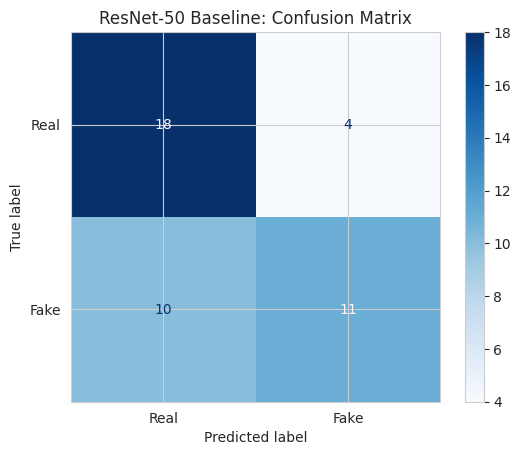

Correctly classified Real (TN): 18
Correctly classified Fake (TP): 11
Real predicted as Fake (FP/FRR errors): 4
Fake predicted as Real (FN/FAR errors): 10


In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
disp.plot(cmap='Blues')
plt.title('ResNet-50 Baseline: Confusion Matrix')
plt.show()

# show fpr, fnr, tnr, tpr.
tn, fp, fn, tp = cm.ravel()
print(f"Correctly classified Real (TN): {tn}")
print(f"Correctly classified Fake (TP): {tp}")
print(f"Real predicted as Fake (FP/FRR errors): {fp}")
print(f"Fake predicted as Real (FN/FAR errors): {fn}")